# Laboratório Agentes Inteligentes

Neste laboratório o código está completo. A sua tarefa é **executar, alterar parâmetros, observar e responder a cinco questões**. Não precisa de escrever funções.

## Como trabalhar
1. Abra este ficheiro no Google Colab e guarde uma cópia no seu Drive.
2. Execute as células pela ordem apresentada, usando o botão ▶. Não é necessária GPU.
3. Nas experiências, altere apenas os valores indicados e volte a executar a mesma célula.
4. Escreva nas células «Resposta» e inclua valores dos resultados. As execuções ficam registadas no histórico enquanto a sessão estiver ativa.
5. Entregue o notebook com respostas e resultados guardados. Reiniciar a sessão apaga as variáveis: nesse caso repita as experiências.

**Todo o código está visível.** As funções da primeira célula podem ser lidas e discutidas. Para as experiências, só precisa de alterar os parâmetros indicados.

**Objetivos:** distinguir perceção de estado real, comparar agentes sem memória e com memória, compreender a medida de desempenho e verificar os limites de um modelo.

## O mundo do robô

Neste laboratório, vamos observar um robô aspirador que limpa duas salas, **A e B**. Queremos perceber como a forma de decidir influencia o seu comportamento e os resultados.

### O que consegue observar e fazer?

As duas salas começam sujas e o robô começa na sala A. Só consegue detetar sujidade **na sala onde está**: não vê diretamente o estado da outra sala.

Em cada ciclo da simulação, executa uma ação:

- **Aspirar:** limpar a sala onde está.
- **Mudar de sala:** passar de A para B ou de B para A.
- **Esperar:** ficar onde está, sem aspirar.

**Um ciclo de decisão inclui esta sequência:**

**Observar a sala → decidir → executar a ação.**

A ação pode ser **aspirar, mudar de sala ou esperar**. Portanto, um ciclo não significa necessariamente uma deslocação física. Esperar também conta como um ciclo.

Um ciclo não corresponde a um tempo em segundos. Por exemplo, aspirar A, mudar para B e aspirar B ocupa três ciclos.

Vamos assumir que os sensores detetam corretamente a sujidade e que os movimentos e a aspiração funcionam sem falhas.

### Que formas de decidir vamos comparar?

Vamos experimentar três versões do programa do robô.

**1. Agente sem memória (reflexo simples)**

Decide apenas com o que observa na sala onde está. Se a sala está suja, aspira. Se está limpa, muda de sala. Não usa informação das visitas anteriores para decidir.

**2. Agente com memória permanente**

Guarda informação sobre as salas que observou e limpou. Se a sala atual está suja, aspira. Se considera ambas limpas, espera; caso contrário, muda de sala.

**«Permanente» significa que a informação não tem prazo de validade. Não significa que nunca pode ser alterada.**

- Se a sala onde está ficar suja, o robô deteta a sujidade na observação seguinte, atualiza a memória e aspira. Depois de aspirar, regista essa sala como limpa.
- Se a outra sala ficar suja, o robô não observa essa alteração. Continua a recordá-la como limpa até voltar lá.

Por exemplo: o robô limpou A e B e ficou em B. Se surgir sujidade em A, pode continuar a esperar em B, porque ainda considera A limpa.

**3. Agente com memória temporária**

Também guarda e atualiza informação sobre as salas, mas cada observação tem um **prazo de validade**, contado em ciclos. Observar novamente uma sala renova esse prazo.

Por exemplo, com validade de **3 ciclos**:

1. Observa A no ciclo 1 e regista-a como limpa depois de aspirar.
2. Desloca-se para B e deixa de observar A.
3. No início do ciclo 4, se não tiver observado A entretanto, essa informação tem 3 ciclos de idade e passa de «limpa» para **«desconhecida» (`?`)**.
4. O robô precisa de voltar a A para verificar e atualizar a memória. Se a sala onde está tiver sujidade, aspira primeiro; caso contrário, desloca-se para a outra sala.

**A informação expirar não significa que a sala ficou suja.** Significa apenas: «Já passou algum tempo; preciso de confirmar.»

Esta revisão pode ajudar a descobrir nova sujidade, mas também exige deslocações para verificar as salas.

Nas primeiras experiências, não aparece nova sujidade. Mais à frente, vamos permitir que as salas voltem a ficar sujas, para observar os limites de cada forma de decidir.

### O que vemos na simulação?

As tabelas mostram-nos o estado verdadeiro das duas salas. As colunas «Memória A» e «Memória B» aparecem apenas nos agentes com memória. Isso permite comparar **o que realmente acontece** com **o que o robô considera que acontece**.

O robô não recebe toda a informação mostrada na tabela: só observa a sala onde está. A sua memória pode, por isso, estar desatualizada.

### Como avaliamos o comportamento?

Vamos usar duas medidas diferentes.

**1. Pontuação**

O robô ganha **10 pontos por cada limpeza efetiva** e perde pontos por cada deslocação:

**Pontuação = 10 × número de limpezas − custo de movimento × número de deslocações**

Por exemplo, duas limpezas e três deslocações, com custo de movimento igual a 1, dão:

**20 − 3 = 17 pontos.**

Esperar não altera a pontuação. Aspirar não tem um custo adicional nesta regra simplificada.

**2. Limpeza média das salas**

Depois de cada ação, verificamos quantas salas estão limpas:

- Nenhuma: **0%**.
- Uma: **50%**.
- As duas: **100%**.

No final, calculamos a média desses valores. Esta medida mostra até que ponto as salas se mantiveram limpas durante a experiência. **Não entra no cálculo da pontuação.**


In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

historico = []


def tipos_agentes(validade):
    """Escolhe o nome da versão com memória a partir do prazo indicado."""
    nome = ("Agente com memória permanente" if validade is None
            else "Agente com memória temporária")
    return ("Agente sem memória", nome)


def simular(tipo, ciclos=12, custo=1, prob_sujidade=0, semente=7,
            validade=None):
    """Simulação didática. A mesma semente gera os mesmos eventos externos."""
    assert tipo in ("Agente sem memória", "Agente com memória permanente",
                    "Agente com memória temporária")
    if tipo == "Agente com memória temporária":
        assert validade is not None, "Defina o prazo da memória temporária."
    else:
        validade = None
    assert isinstance(ciclos, int) and ciclos > 0
    assert custo >= 0 and 0 <= prob_sujidade <= 1
    assert validade is None or (isinstance(validade, int) and validade >= 1)
    rng = random.Random(semente)
    # Eventos sorteados antes da execução, independentemente das ações.
    eventos = [[rng.random() < prob_sujidade for _ in range(2)]
               for _ in range(ciclos)]
    salas = [True, True]  # True = suja
    pos = 0
    usa_memoria = tipo != "Agente sem memória"
    memoria = [None, None] if usa_memoria else None
    observado_em = [-1, -1] if usa_memoria else None
    pontos = limpezas = movimentos = 0
    registos = []
    for t in range(ciclos):
        if t > 0:  # o estado inicial é sempre igual
            salas = [suja or evento for suja, evento in zip(salas, eventos[t])]
        if validade is not None:
            for i in range(2):
                if memoria[i] is not None and t - observado_em[i] >= validade:
                    memoria[i] = None
        antes = pos
        percecao = salas[pos]
        if usa_memoria:
            memoria[pos] = percecao
            observado_em[pos] = t
        if percecao:
            acao = "Aspirar"
            salas[pos] = False
            if usa_memoria:
                memoria[pos] = False  # aspirar tem efeito conhecido e fiável
            pontos += 10
            limpezas += 1
        elif tipo != "Agente sem memória" and all(m is False for m in memoria):
            acao = "Esperar"
        else:
            acao = "Mudar de sala"
            pos = 1 - pos
            pontos -= custo
            movimentos += 1
        nome_estado = lambda x: "?" if x is None else ("Suja" if x else "Limpa")
        registo = {"Ciclo": t + 1, "Sala observada": "AB"[antes],
            "Perceção": nome_estado(percecao), "Ação": acao,
            "Posição final": "AB"[pos],
            "A real": nome_estado(salas[0]), "B real": nome_estado(salas[1]),
            "Pontuação": pontos,
            "% salas limpas": 100 * sum(not s for s in salas) / 2}
        if usa_memoria:
            registo["Memória A"] = nome_estado(memoria[0])
            registo["Memória B"] = nome_estado(memoria[1])
        registos.append(registo)
    df = pd.DataFrame(registos)
    if usa_memoria:
        ordem = ["Ciclo", "Sala observada", "Perceção", "Ação", "Posição final",
                 "A real", "B real", "Memória A", "Memória B", "Pontuação", "% salas limpas"]
        df = df[ordem]
    resumo = {"Limpezas": limpezas, "Deslocações": movimentos,
              "Pontuação final": pontos,
              "Limpeza média (%)": round(df["% salas limpas"].mean(), 2)}
    return df, resumo


def comparar(etapa, ciclos=12, custo=1, prob_sujidade=0, semente=7,
             validade=None, detalhes=False):
    linhas = []
    fig, ax = plt.subplots(figsize=(8, 3))
    for tipo in tipos_agentes(validade):
        df, resumo = simular(tipo, ciclos, custo, prob_sujidade, semente,
                            validade if tipo != "Agente sem memória" else None)
        linha = dict(Etapa=etapa, Agente=tipo, Ciclos=ciclos, Custo=custo,
                     Probabilidade=prob_sujidade, Semente=semente,
                     Validade=validade, **resumo)
        historico.append(linha)
        linhas.append(linha)
        ax.plot(df["Ciclo"], df["Pontuação"], marker=".", label=tipo)
        if detalhes:
            print("\n" + tipo)
            print("Sala observada e perceção: início do ciclo. Estado real e memória: depois da ação.")
            print("A real e B real são mostradas ao aluno; o agente só observa a sala atual.")
            display(HTML(df.to_html(index=False)))
    ax.set(xlabel="Ciclo", ylabel="Pontuação acumulada")
    ax.legend(); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
    display(pd.DataFrame(linhas)[["Agente", "Limpezas", "Deslocações",
                                 "Pontuação final", "Limpeza média (%)"]])

print("Preparação concluída. Pode começar as experiências.")


Preparação concluída. Pode começar as experiências.


## Experiência 1 — Observar os dois agentes
Execute a célula seguinte sem alterar os valores. O código apresenta as ações e o estado das salas em cada ciclo.

**Questão 1.** Registe o número de limpezas, o número de deslocações e a pontuação final de cada agente. Explique, usando o registo de ações, por que motivo um deles continua a mover-se depois de as duas salas estarem limpas.


Agente sem memória
Sala observada e perceção: início do ciclo. Estado real e memória: depois da ação.
A real e B real são mostradas ao aluno; o agente só observa a sala atual.


Ciclo,Sala observada,Perceção,Ação,Posição final,A real,B real,Pontuação,% salas limpas
1,A,Suja,Aspirar,A,Limpa,Suja,10,50.0
2,A,Limpa,Mudar de sala,B,Limpa,Suja,9,50.0
3,B,Suja,Aspirar,B,Limpa,Limpa,19,100.0
4,B,Limpa,Mudar de sala,A,Limpa,Limpa,18,100.0
5,A,Limpa,Mudar de sala,B,Limpa,Limpa,17,100.0
6,B,Limpa,Mudar de sala,A,Limpa,Limpa,16,100.0
7,A,Limpa,Mudar de sala,B,Limpa,Limpa,15,100.0
8,B,Limpa,Mudar de sala,A,Limpa,Limpa,14,100.0
9,A,Limpa,Mudar de sala,B,Limpa,Limpa,13,100.0
10,B,Limpa,Mudar de sala,A,Limpa,Limpa,12,100.0



Agente com memória permanente
Sala observada e perceção: início do ciclo. Estado real e memória: depois da ação.
A real e B real são mostradas ao aluno; o agente só observa a sala atual.


Ciclo,Sala observada,Perceção,Ação,Posição final,A real,B real,Memória A,Memória B,Pontuação,% salas limpas
1,A,Suja,Aspirar,A,Limpa,Suja,Limpa,?,10,50.0
2,A,Limpa,Mudar de sala,B,Limpa,Suja,Limpa,?,9,50.0
3,B,Suja,Aspirar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
4,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
5,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
6,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
7,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
8,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
9,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
10,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0


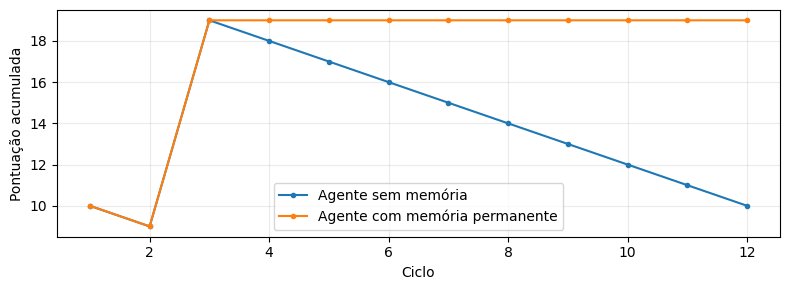

,Agente,Limpezas,Deslocações,Pontuação final,Limpeza média (%)
0,Agente sem memória,2,10,10,91.67
1,Agente com memória permanente,2,1,19,91.67


In [2]:
comparar("1", ciclos=12, custo=1, prob_sujidade=0, detalhes=True)

**Resposta 1:**

Observações e explicação: …

## Experiência 2 — Alterar o custo das deslocações
Na célula seguinte, altere apenas `CUSTO`. Execute com **0, depois 1 e depois 4**. Preencha a tabela da resposta.

**Questão 2.** Compare as pontuações para os três custos e explique se a alteração do custo mudou as ações dos agentes ou apenas a forma de as avaliar. Apoie a resposta no número de deslocações.

In [ ]:
CUSTO = 1  # ALTERAR: executar com 0, depois 1, depois 4
comparar("2", ciclos=12, custo=CUSTO, prob_sujidade=0)

**Resposta 2:**

| Custo | Agente sem memória | Agente com memória permanente | Explicação |
|---|---|---|---|
| 0 | … | … | … |
| 1 | … | … | … |
| 4 | … | … | … |

## Experiência 3 — Alterar a duração
Na célula seguinte, altere apenas `CICLOS`. Execute com **6 e depois 30**, mantendo as restantes condições.

**Questão 3.** Registe as pontuações e o número de limpezas para as duas durações. Explique por que motivo executar durante mais tempo pode piorar a pontuação, mesmo quando as salas já estão limpas.

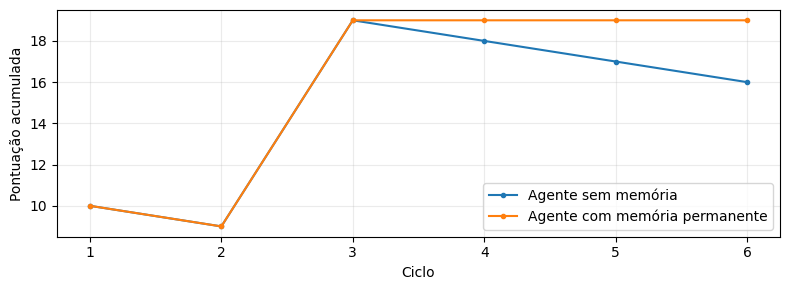

,Agente,Limpezas,Deslocações,Pontuação final,Limpeza média (%)
0,Agente sem memória,2,4,16,83.33
1,Agente com memória permanente,2,1,19,83.33


In [3]:
CICLOS = 6  # ALTERAR: executar com 6 e depois com 30
comparar("3", ciclos=CICLOS, custo=1, prob_sujidade=0)

**Resposta 3:**

| Ciclos | Pontuação do agente sem memória | Pontuação do agente com memória permanente | Limpezas de cada agente |
|---|---|---|---|
| 6 | … | … | … |
| 30 | … | … | … |

Explicação: …

## Experiência 4 — Fazer reaparecer sujidade
Execute três combinações: **probabilidade 0 e semente 7**; **probabilidade 0.20 e semente 7**; **probabilidade 0.20 e semente 21**.

A probabilidade aplica-se a cada sala antes de cada ação, a partir do segundo ciclo. Uma sala já suja não acumula mais sujidade. A semente identifica uma sequência repetível de eventos; os dois agentes usam a mesma sequência.

**Questão 4.** Compare os resultados e identifique, num dos registos com nova sujidade, um ciclo em que a memória indique uma sala limpa mas ela esteja suja. Indique o ciclo e a sala e explique por que motivo a informação guardada deixou de ser fiável.


Agente sem memória
Sala observada e perceção: início do ciclo. Estado real e memória: depois da ação.
A real e B real são mostradas ao aluno; o agente só observa a sala atual.


Ciclo,Sala observada,Perceção,Ação,Posição final,A real,B real,Pontuação,% salas limpas
1,A,Suja,Aspirar,A,Limpa,Suja,10,50.0
2,A,Limpa,Mudar de sala,B,Limpa,Suja,9,50.0
3,B,Suja,Aspirar,B,Limpa,Limpa,19,100.0
4,B,Limpa,Mudar de sala,A,Limpa,Limpa,18,100.0
5,A,Limpa,Mudar de sala,B,Limpa,Limpa,17,100.0
6,B,Limpa,Mudar de sala,A,Limpa,Limpa,16,100.0
7,A,Limpa,Mudar de sala,B,Limpa,Limpa,15,100.0
8,B,Limpa,Mudar de sala,A,Limpa,Limpa,14,100.0
9,A,Limpa,Mudar de sala,B,Limpa,Limpa,13,100.0
10,B,Limpa,Mudar de sala,A,Limpa,Limpa,12,100.0



Agente com memória permanente
Sala observada e perceção: início do ciclo. Estado real e memória: depois da ação.
A real e B real são mostradas ao aluno; o agente só observa a sala atual.


Ciclo,Sala observada,Perceção,Ação,Posição final,A real,B real,Memória A,Memória B,Pontuação,% salas limpas
1,A,Suja,Aspirar,A,Limpa,Suja,Limpa,?,10,50.0
2,A,Limpa,Mudar de sala,B,Limpa,Suja,Limpa,?,9,50.0
3,B,Suja,Aspirar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
4,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
5,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
6,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
7,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
8,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
9,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0
10,B,Limpa,Esperar,B,Limpa,Limpa,Limpa,Limpa,19,100.0


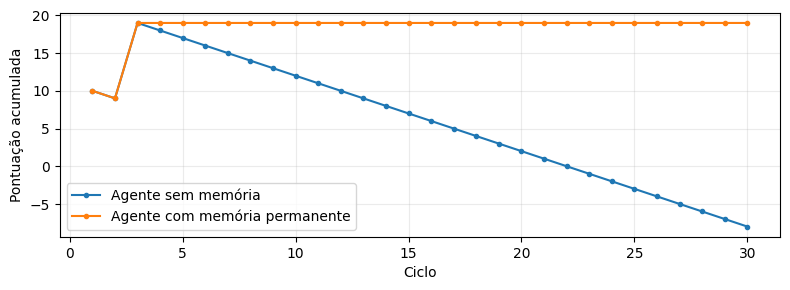

,Agente,Limpezas,Deslocações,Pontuação final,Limpeza média (%)
0,Agente sem memória,2,28,-8,96.67
1,Agente com memória permanente,2,1,19,96.67


In [4]:
PROBABILIDADE = 0.0  # ALTERAR: 0.0 e depois 0.20
SEMENTE = 7  # com probabilidade 0.20, repetir também com 21
comparar("4", ciclos=30, custo=1, prob_sujidade=PROBABILIDADE,
         semente=SEMENTE, detalhes=True)

**Resposta 4:**

Exemplo de memória desatualizada: …

Resultados com semente 7: …

Resultados com semente 21: …

Explicação: …

## Experiência 5 — Voltar a verificar informação antiga
Execute com `VALIDADE` igual a **None, depois 3 e depois 8**. `None` seleciona o **agente com memória permanente**. Os valores 3 e 8 selecionam o **agente com memória temporária**, com o prazo indicado. Um número faz uma observação antiga passar a desconhecida após esse número de ciclos; o robô terá de voltar a observar essa sala.

O código repete cada comparação em **20 sementes**. Na tabela, `mean` é a média e `std` indica a variação entre execuções.

**Questão 5.** Preencha a tabela com as médias da pontuação, da limpeza e das deslocações para cada validade. Explique o compromisso entre voltar a verificar as salas e gastar mais em deslocações. Use os resultados para justificar por que motivo ter memória, por si só, não garante melhor desempenho.

### Como ler os gráficos
Depois da tabela, aparecem três gráficos de barras com as **médias de 20 execuções**:
- **Pontuação média:** avaliação que combina limpezas e custo das deslocações.
- **Limpeza média (%):** percentagem de salas limpas, em média ao longo dos ciclos.
- **Deslocações médias:** número médio de mudanças de sala por execução.

Os gráficos reúnem as configurações da Experiência 5 que já executou nesta sessão. Primeiro, verá o agente sem memória e a memória permanente. Depois de executar também com `VALIDADE = 3` e `VALIDADE = 8`, verá as quatro versões lado a lado. Repetir uma configuração não duplica os seus resultados nos gráficos.

Cada barra apresenta o valor médio. O agente sem memória aparece apenas uma vez como referência. Os gráficos comparam médias entre agentes; não mostram a evolução ciclo a ciclo. Se voltar a executar a célula de preparação, o histórico é reiniciado.


Validade da memória: 8 | 20 sementes por agente


Limpezas       Deslocações        \
                                  mean   std        mean   std   
Agente                                                           
Agente com memória temporária     17.6  3.02         7.7  0.47   
Agente sem memória                22.6  3.15        37.4  3.15   

                              Pontuação final        Limpeza média (%)        
                                         mean    std              mean   std  
Agente                                                                        
Agente com memória temporária           168.3  30.38             68.12  6.69  
Agente sem memória                      188.6  34.68             84.42  3.44

mean = média; std = desvio-padrão (variação entre execuções).


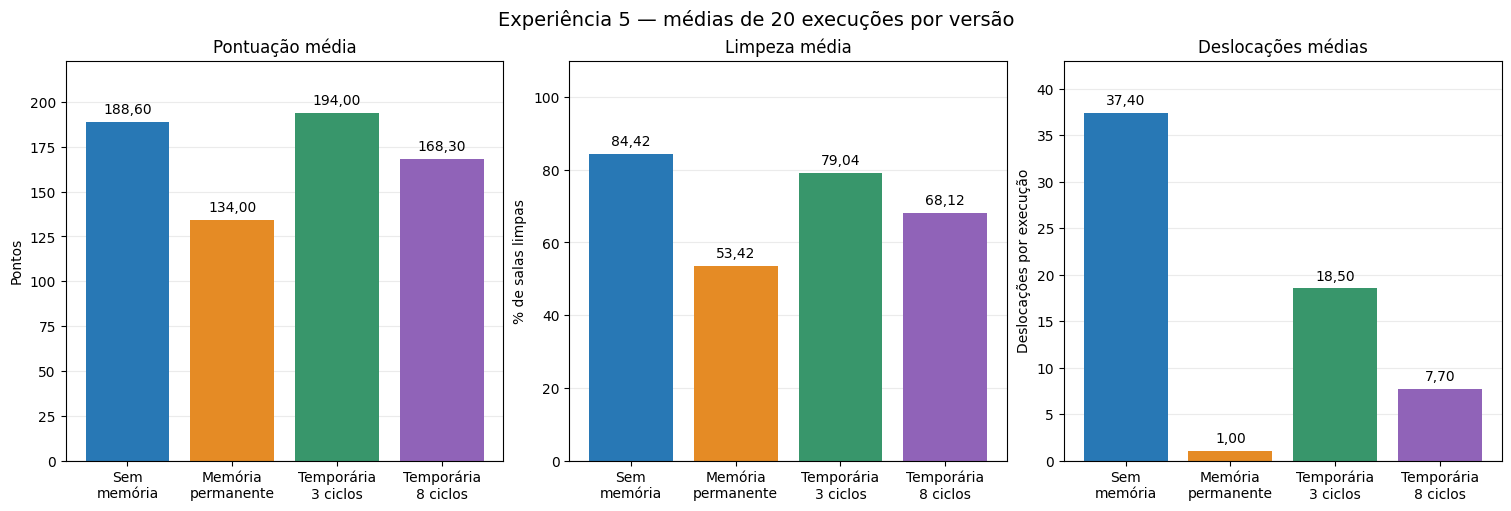

Os gráficos incluem as quatro versões do agente.


In [7]:
VALIDADE = 8  # ALTERAR: None, depois 3, depois 8
linhas = []
for semente in range(20):
    for tipo in tipos_agentes(VALIDADE):
        _, resumo = simular(tipo, ciclos=60, custo=1, prob_sujidade=0.20,
                            semente=semente,
                            validade=VALIDADE if tipo != "Agente sem memória" else None)
        linha = dict(Etapa="5", Agente=tipo, Ciclos=60, Custo=1,
                     Probabilidade=0.20, Semente=semente,
                     Validade=VALIDADE, **resumo)
        linhas.append(linha)
        historico.append(linha)
print("Validade da memória:", VALIDADE, "| 20 sementes por agente")
display(pd.DataFrame(linhas).groupby("Agente")[
    ["Limpezas", "Deslocações", "Pontuação final", "Limpeza média (%)"]]
    .agg(["mean", "std"]).round(2))
print("mean = média; std = desvio-padrão (variação entre execuções).")

# Reunir os resultados já obtidos nesta experiência.
# Usamos as mesmas condições: 60 ciclos, custo 1 e probabilidade 0.20.
dados_graficos = pd.DataFrame([
    registo for registo in historico
    if registo["Etapa"] == "5"
    and registo["Ciclos"] == 60
    and registo["Custo"] == 1
    and registo["Probabilidade"] == 0.20
    and registo["Semente"] in range(20)
])


def nome_no_grafico(registo):
    if registo["Agente"] == "Agente sem memória":
        return "Sem memória"
    if pd.isna(registo["Validade"]):
        return "Memória permanente"
    return f"Memória temporária ({int(registo['Validade'])} ciclos)"


dados_graficos["Versão"] = dados_graficos.apply(nome_no_grafico, axis=1)
# A mesma semente só conta uma vez em cada versão, mesmo após reexecuções.
dados_graficos = dados_graficos.drop_duplicates(
    subset=["Versão", "Semente"], keep="last"
)
ordem = ["Sem memória", "Memória permanente",
         "Memória temporária (3 ciclos)", "Memória temporária (8 ciclos)"]
presentes = [nome for nome in ordem if nome in dados_graficos["Versão"].values]
medias = dados_graficos.groupby("Versão")[[
    "Pontuação final", "Limpeza média (%)", "Deslocações"
]].mean().reindex(presentes)

# Cada gráfico usa a sua própria unidade e escala.
paineis = [
    ("Pontuação final", "Pontuação média", "Pontos"),
    ("Limpeza média (%)", "Limpeza média", "% de salas limpas"),
    ("Deslocações", "Deslocações médias", "Deslocações por execução")
]
rotulos = {"Sem memória": "Sem\nmemória",
           "Memória permanente": "Memória\npermanente",
           "Memória temporária (3 ciclos)": "Temporária\n3 ciclos",
           "Memória temporária (8 ciclos)": "Temporária\n8 ciclos"}
paleta = dict(zip(ordem, ["#2878B5", "#E58B25", "#38966B", "#9063B8"]))
fig, eixos = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for eixo, (coluna, titulo, unidade) in zip(eixos, paineis):
    barras = eixo.bar([rotulos[nome] for nome in presentes], medias[coluna],
                      color=[paleta[nome] for nome in presentes])
    eixo.bar_label(barras,
                   labels=[f"{valor:.2f}".replace(".", ",")
                           for valor in medias[coluna]], padding=4)
    eixo.set_title(titulo)
    eixo.set_ylabel(unidade)
    eixo.set_axisbelow(True)
    eixo.grid(axis="y", alpha=0.25)
    eixo.axhline(0, color="gray", linewidth=0.8)
    if coluna == "Limpeza média (%)":
        eixo.set_ylim(0, 110)  # espaço para os rótulos; a percentagem máxima é 100
        eixo.set_yticks(range(0, 101, 20))
    else:
        minimo = min(0, medias[coluna].min())
        maximo = max(0, medias[coluna].max())
        margem = max(1, (maximo - minimo) * 0.15)
        eixo.set_ylim(minimo - margem if minimo < 0 else 0, maximo + margem)
fig.suptitle("Experiência 5 — médias de 20 execuções por versão", fontsize=14)
plt.show()

em_falta = [nome for nome in ordem[1:] if nome not in presentes]
if em_falta:
    print("Para completar os gráficos, execute também: " + ", ".join(em_falta) + ".")
else:
    print("Os gráficos incluem as quatro versões do agente.")


**Resposta 5:**

| Validade | Pontuação média da memória | Limpeza média (%) | Deslocações médias |
|---|---|---|---|
| None | … | … | … |
| 3 | … | … | … |
| 8 | … | … | … |

Explicação e proposta de medida: …